# TinyML Fall Detection — Binary Linear Model

Questo notebook sostituisce il precedente modello one-class a prototipi con un classificatore binario leggero:

- `NORMAL = 0`
- `FALL = 1`

Il modello usa feature estratte da finestre di 20 campioni e addestra una `LogisticRegression` lineare.  
L'inferenza esportata in C è semplice:

```c
score = bias + sum(weights[i] * ((features[i] - mean[i]) / scale[i]));

if(score >= threshold) {
    FALL;
} else {
    NORMAL;
}
```

Lo split resta coerente con il vincolo richiesto:

- 6 template FALL per training/validation
- 2 template FALL held-out per test


In [16]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple
import json

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

RANDOM_SEED = 42

# Dataset split:
# Il template 7 viene tenuto nel training perché ha una dinamica diversa dagli altri.
# I template 5 e 6 vengono lasciati fuori come test held-out.
NUM_TOTAL_TEMPLATES = 8
TRAIN_TEMPLATE_IDS = np.array([0, 1, 2, 3, 4, 7], dtype=np.int32)
TEST_TEMPLATE_IDS = np.array([5, 6], dtype=np.int32)

WINDOW_SIZE = 20
NUM_CHANNELS = 9

TRAIN_VARIANTS_PER_TEMPLATE = 2000
VALIDATION_VARIANTS_PER_TEMPLATE = 500

NUM_NORMAL_TRAIN_WINDOWS = 12000
NUM_NORMAL_VALIDATION_WINDOWS = 3000
NUM_NORMAL_TEST_WINDOWS = 10000

ACC_NOISE_MG = 30
GYRO_NOISE_DPS = 5

TARGET_RECALL = 0.99

FEATURE_NAMES = [
    "adxl_mean", "adxl_variance", "adxl_min", "adxl_max",
    "adxl_range", "adxl_mean_abs_diff", "adxl_max_abs_diff",
    "gyro_mean", "gyro_variance", "gyro_min", "gyro_max",
    "gyro_range", "gyro_mean_abs_diff", "gyro_max_abs_diff",
    "mma_mean", "mma_variance", "mma_min", "mma_max",
    "mma_range", "mma_mean_abs_diff", "mma_max_abs_diff",
]

NUM_FEATURES = len(FEATURE_NAMES)

print("Configuration loaded.")
print("TRAIN_TEMPLATE_IDS:", TRAIN_TEMPLATE_IDS)
print("TEST_TEMPLATE_IDS:", TEST_TEMPLATE_IDS)
print("NUM_FEATURES:", NUM_FEATURES)


Configuration loaded.
TRAIN_TEMPLATE_IDS: [0 1 2 3 4 7]
TEST_TEMPLATE_IDS: [5 6]
NUM_FEATURES: 21


## 1. Dati incorporati dal generatore C

Unità:

- ADXL345 e MMA8451Q: milli-g
- ITG3200: gradi al secondo

Ordine dei 9 canali:

```text
adxl_x, adxl_y, adxl_z,
gyro_x, gyro_y, gyro_z,
mma_x, mma_y, mma_z
```


In [17]:
NORMAL_QUANTILES = np.array(
[[-996, -215, -55, 12, 90, 223, 1008], [-2621, -1215, -1004, -949, -758, -168, 375], [-1219, -574, -340, -141, 74, 316, 934], [-120, -26, -6, -1, 6, 27, 117], [-93, -24, -3, 3, 8, 29, 96], [-79, -22, -4, 0, 3, 21, 77], [-986, -214, -60, 4, 69, 198, 978], [-2537, -1187, -982, -927, -747, -162, 353], [-1193, -547, -293, -83, 126, 373, 991]],
    dtype=np.int32,
)

FALL_TEMPLATES = np.array(
[[[-66, -699, -629, -27, 5, 23, -55, -714, -633], [-176, -605, -730, -36, 20, 42, -163, -598, -728], [-195, -465, -789, -21, 20, 36, -186, -487, -777], [-195, -426, -805, -6, 9, 22, -172, -424, -821], [-184, -422, -816, 7, 27, 31, -172, -426, -813], [-125, -375, -691, 5, 62, 20, -113, -388, -684], [-86, -449, -906, -52, 39, 29, -81, -426, -912], [242, -270, -766, -102, 152, -49, 247, -264, -759], [1387, 422, 281, -10, 144, 58, 1379, 421, 299], [727, -199, 488, 58, 34, 5, 719, -201, 511], [984, -180, 152, 7, -60, -16, 978, -194, 194], [1043, 148, -59, -21, -60, -6, 1031, 138, -24], [973, 8, -238, -15, -24, 11, 968, 16, -228], [945, -98, -312, -1, -5, -1, 938, -92, -303], [953, 16, -262, 5, 6, -5, 959, 23, -247], [973, 0, -242, 3, 1, 1, 959, -1, -240], [961, -8, -250, 3, -4, -1, 951, -4, -228], [957, 0, -277, 3, -1, -1, 950, -2, -268], [965, -8, -297, 4, 2, -1, 961, 3, -260], [957, 0, -266, 3, 1, 0, 959, 8, -245]], [[102, -855, 367, 5, 2, 0, 20, -814, 529], [90, -828, 395, 9, 3, -1, 9, -795, 560], [90, -801, 453, 12, 7, -4, 9, -772, 598], [117, -797, 473, 13, 11, -1, 31, -779, 631], [94, -711, 527, 26, 18, 5, 18, -681, 689], [39, -609, 598, 39, 24, 3, -37, -592, 758], [-35, -438, 590, 68, 43, 20, -147, -417, 755], [-125, -82, 309, 98, 98, 49, -205, -77, 482], [-2758, 715, 820, 56, -86, 19, -2737, 735, 1002], [-859, 180, -39, -35, -8, -30, -908, 192, 121], [-191, -625, 1043, -40, 28, -47, -280, -590, 1201], [-703, -39, 516, -1, -4, 7, -766, -36, 688], [-699, -4, 500, 4, -8, -2, -762, 10, 681], [-648, 51, 555, 7, 0, 2, -706, 55, 710], [-656, 8, 531, 4, -3, 1, -732, 29, 714], [-621, 62, 559, -1, 2, -1, -688, 64, 722], [-629, 43, 543, -2, -1, 1, -689, 53, 728], [-625, 35, 562, -4, 2, -1, -688, 41, 723], [-605, 43, 551, -2, 2, 0, -683, 55, 718], [-633, 31, 562, -3, 0, -1, -686, 46, 736]], [[20, -984, -168, 3, 0, 1, 57, -950, -209], [39, -977, -191, 7, -4, -3, 55, -943, -192], [43, -941, -164, 0, -3, -5, 67, -911, -203], [8, -883, -176, -13, -13, 11, 35, -845, -220], [70, -852, -172, -4, 3, 23, 99, -820, -205], [-121, -898, -145, 10, 10, 34, -95, -858, -186], [-117, -941, -234, 16, 14, 47, -104, -901, -265], [-363, -828, -195, 4, -29, 49, -335, -812, -223], [-1918, -1016, 664, 55, -105, 156, -1824, -1010, 626], [-875, 35, 871, 91, -35, 220, -833, 36, 852], [-562, 543, -4, 98, 32, 48, -557, 491, -19], [-605, 527, 145, 29, 18, -118, -607, 501, 122], [-1055, -160, -121, -4, 31, -6, -1030, -173, -139], [-1000, -74, -35, -4, -22, 0, -994, -74, -42], [-949, 74, 273, 7, -3, 6, -923, 58, 233], [-1023, 39, 82, -1, 9, -3, -1010, 25, 82], [-977, -20, 184, -5, -2, -1, -952, -26, 172], [-992, 0, 172, 2, 5, -1, -976, -14, 148], [-1027, 12, 137, 1, 1, -2, -1005, -7, 139], [-988, -12, 203, -3, 5, -2, -966, -21, 178]], [[8, -844, -324, -22, -12, 5, -11, -876, -308], [-39, -836, -414, -38, -6, 7, -59, -860, -412], [-55, -746, -504, -32, 0, 0, -56, -766, -509], [-39, -645, -602, -30, -4, 0, -54, -656, -621], [-66, -672, -762, -13, -3, 3, -75, -696, -772], [-43, -688, -805, -3, 4, 34, -50, -698, -826], [129, -402, -582, 23, -66, 9, 113, -439, -580], [-137, -539, -660, 9, -77, 4, -136, -547, -656], [-2137, -1328, 102, 67, -238, 86, -2105, -1320, 111], [-766, 246, 1012, 77, -45, 81, -802, 174, 1036], [-699, 191, 188, 4, -86, 14, -752, 140, 197], [-520, -219, 1047, -30, -37, -34, -602, -229, 1083], [-297, -355, 777, 25, 30, -41, -344, -372, 810], [-590, -203, 777, 54, 4, -28, -642, -224, 828], [-555, -191, 750, -6, 23, 2, -610, -203, 771], [-586, -117, 727, 5, 3, 4, -637, -145, 755], [-570, -242, 809, -5, -15, -5, -637, -263, 823], [-469, -266, 797, 5, 8, -3, -519, -296, 823], [-621, -188, 730, 5, 8, 2, -655, -218, 745], [-559, -219, 746, 3, -10, 1, -630, -252, 759]], [[422, -1469, -1023, -6, 23, 0, 432, -1478, -1047], [102, -844, -441, -6, -23, 11, 112, -857, -444], [121, -496, -270, 20, 7, 25, 118, -517, -273], [-125, -1223, -1082, -33, -44, -9, -99, -1258, -1097], [31, -883, -578, -24, 7, -15, 46, -896, -591], [-4, -531, -426, -25, -42, -27, 23, -545, -447], [-117, -797, -527, -74, -31, -22, -97, -798, -539], [-297, -375, -113, 33, -190, -19, -314, -387, -104], [-3820, -344, -1707, -111, -316, 195, -3748, -396, -1716], [-367, 426, 199, 88, 101, 57, -377, 405, 171], [-867, 582, -273, -7, 12, 3, -867, 584, -275], [-875, 492, -465, 45, 34, 3, -875, 484, -482], [-902, 184, -281, 35, 4, 22, -902, 170, -256], [-684, 500, -574, -1, 9, -3, -682, 504, -591], [-770, 480, -551, 5, -18, -7, -785, 489, -597], [-723, 445, -504, 4, 1, -4, -734, 429, -515], [-770, 445, -527, 2, -2, -1, -773, 441, -544], [-746, 484, -559, -1, 9, 5, -750, 474, -589], [-723, 496, -570, 1, 11, 6, -716, 490, -590], [-711, 512, -605, 3, 16, 5, -702, 507, -633]], [[59, -957, 62, 23, -15, 10, 87, -912, 21], [199, -1215, -289, 10, 50, -41, 207, -1161, -335], [250, -734, -113, 15, 40, 8, 260, -711, -140], [4, -895, -78, -10, 85, 8, 32, -852, -111], [-117, -1316, 78, -26, 108, 32, -103, -1242, 50], [-43, -691, -215, -28, 138, 8, -17, -659, -255], [4, -375, -238, -48, 152, 44, 17, -342, -266], [285, -789, -199, -52, 65, -10, 297, -749, -229], [1703, -2922, 250, 180, 128, -137, 1746, -2741, 194], [285, 402, 488, 12, -1, -106, 293, 431, 471], [117, 277, 469, -7, 42, 38, 126, 278, 453], [496, -262, 840, 1, -23, -12, 520, -232, 818], [1043, -281, 309, -2, -17, 13, 1045, -240, 268], [898, -98, 352, -3, 9, -7, 906, -73, 306], [906, -70, 395, 1, 8, 3, 907, -45, 366], [910, -121, 352, 5, 5, 1, 907, -87, 306], [1000, -129, 211, -10, -6, -2, 998, -81, 181], [938, 0, 383, 2, 9, -1, 933, 11, 351], [945, -78, 328, 6, 7, 2, 946, -28, 297], [910, -74, 367, -1, 8, 1, 903, -39, 342]], [[316, -1039, 27, 1, -9, 1, 277, -1022, 86], [-94, -898, -543, -14, 1, 12, -117, -878, -505], [4, -863, -74, 15, 11, 37, -13, -846, -27], [-223, -906, 31, 11, 35, -11, -232, -868, 100], [-332, -1496, -305, -34, -14, -3, -349, -1448, -248], [-164, -922, -211, -6, -27, 8, -190, -878, -143], [246, -809, 62, 101, -2, -1, 208, -779, 133], [-51, -121, -309, 89, -61, -15, -73, -144, -235], [-789, -1504, 2344, 324, 92, 128, -804, -1347, 2397], [-594, 543, 801, -21, -2, 11, -600, 554, 861], [-219, 164, 1016, -27, -5, 2, -215, 178, 1082], [-191, -82, 883, -24, 5, 2, -191, -62, 945], [-340, -121, 871, -4, 13, 0, -350, -105, 938], [-270, -39, 914, 0, 4, 1, -267, -31, 967], [-230, -59, 945, -2, 4, -1, -224, -46, 1012], [-262, -59, 875, -1, 4, 0, -258, -49, 947], [-238, -62, 918, -2, 3, 0, -238, -46, 978], [-234, -62, 895, -1, 2, 0, -238, -58, 959], [-234, -55, 906, 0, 3, 0, -222, -54, 976], [-227, -62, 902, -2, 4, -1, -232, -52, 973]], [[-203, -1523, 281, 5, -39, 55, -240, -1559, 280], [-125, 43, -258, 4, 20, 2, -161, 23, -261], [273, -1547, 98, -5, 54, -60, 204, -1567, 94], [-215, -746, -340, -11, -2, 10, -222, -773, -343], [-367, -625, -242, -12, 0, 10, -408, -633, -239], [-215, -1055, -1312, -60, -13, 0, -217, -1075, -1342], [-410, 78, 887, -174, -19, 5, -470, 31, 903], [-426, 637, 238, -73, 0, -2, -450, 613, 252], [-824, 543, -539, -126, -114, 37, -849, 549, -520], [-367, 1277, -184, -32, 19, 16, -391, 1307, -208], [-254, 301, -785, 6, 7, -6, -262, 280, -812], [-367, 168, -922, 7, -10, -7, -360, 137, -931], [-379, 273, -984, 1, -4, 0, -377, 261, -1015], [-379, 285, -859, 8, -1, -3, -372, 263, -896], [-363, 250, -871, 10, 7, 0, -366, 238, -902], [-344, 234, -930, 9, 6, 0, -361, 207, -956], [-363, 234, -871, 4, -1, -1, -360, 194, -909], [-344, 211, -871, 2, 0, -1, -358, 199, -898], [-359, 230, -879, 4, 1, -1, -359, 199, -916], [-355, 219, -859, 2, 1, -1, -359, 197, -902]]],
    dtype=np.int32,
)

TRAIN_FALL_TEMPLATES = FALL_TEMPLATES[TRAIN_TEMPLATE_IDS]
TEST_FALL_TEMPLATES = FALL_TEMPLATES[TEST_TEMPLATE_IDS]

print("Train templates:", TRAIN_TEMPLATE_IDS)
print("Test templates:", TEST_TEMPLATE_IDS)
print("Train FALL templates:", TRAIN_FALL_TEMPLATES.shape)
print("Test FALL templates:", TEST_FALL_TEMPLATES.shape)

assert NORMAL_QUANTILES.shape == (9, 7)
assert FALL_TEMPLATES.shape == (8, 20, 9)

print("NORMAL_QUANTILES:", NORMAL_QUANTILES.shape)
print("FALL_TEMPLATES:", FALL_TEMPLATES.shape)


Train templates: [0 1 2 3 4 7]
Test templates: [5 6]
Train FALL templates: (6, 20, 9)
Test FALL templates: (2, 20, 9)
NORMAL_QUANTILES: (9, 7)
FALL_TEMPLATES: (8, 20, 9)


## 2. Feature extraction

Per ciascuno dei tre sensori si calcola il modulo quadratico:

```text
adxl_mag2 = ax² + ay² + az²
gyro_mag2 = gx² + gy² + gz²
mma_mag2  = mx² + my² + mz²
```

Da ogni segnale vengono estratte 7 feature:

```text
mean, variance, min, max, range, mean_abs_diff, max_abs_diff
```

Totale: `3 sensori × 7 feature = 21 feature`.


In [18]:
def squared_magnitudes(window: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    window = np.asarray(window, dtype=np.float64)

    if window.shape != (WINDOW_SIZE, NUM_CHANNELS):
        raise ValueError(f"Expected {(WINDOW_SIZE, NUM_CHANNELS)}, got {window.shape}.")

    adxl_mag2 = np.sum(window[:, 0:3] ** 2, axis=1)
    gyro_mag2 = np.sum(window[:, 3:6] ** 2, axis=1)
    mma_mag2 = np.sum(window[:, 6:9] ** 2, axis=1)

    return adxl_mag2, gyro_mag2, mma_mag2


def signal_features(signal: np.ndarray) -> np.ndarray:
    signal = np.asarray(signal, dtype=np.float64)

    if signal.ndim != 1 or len(signal) != WINDOW_SIZE:
        raise ValueError(f"Expected a signal of length {WINDOW_SIZE}.")

    differences = np.abs(np.diff(signal))

    return np.array(
        [
            np.mean(signal),
            np.var(signal),
            np.min(signal),
            np.max(signal),
            np.max(signal) - np.min(signal),
            np.mean(differences) if differences.size else 0.0,
            np.max(differences) if differences.size else 0.0,
        ],
        dtype=np.float64,
    )


def extract_features(window: np.ndarray) -> np.ndarray:
    window = np.asarray(window, dtype=np.float64)

    if window.shape != (WINDOW_SIZE, NUM_CHANNELS):
        raise ValueError(f"Expected {(WINDOW_SIZE, NUM_CHANNELS)}, got {window.shape}.")

    adxl_mag2, gyro_mag2, mma_mag2 = squared_magnitudes(window)

    features = np.concatenate(
        [
            signal_features(adxl_mag2),
            signal_features(gyro_mag2),
            signal_features(mma_mag2),
        ]
    )

    if features.shape != (NUM_FEATURES,):
        raise RuntimeError(f"Unexpected feature shape: {features.shape}")

    return features


example_features = extract_features(FALL_TEMPLATES[0])
dict(zip(FEATURE_NAMES, example_features))


{'adxl_mean': np.float64(995851.8),
 'adxl_variance': np.float64(86285086315.85999),
 'adxl_min': np.float64(633731.0),
 'adxl_max': np.float64(2180814.0),
 'adxl_range': np.float64(1547083.0),
 'adxl_mean_abs_diff': np.float64(234718.15789473685),
 'adxl_max_abs_diff': np.float64(1462594.0),
 'gyro_mean': np.float64(4615.25),
 'gyro_variance': np.float64(78396588.6875),
 'gyro_min': np.float64(10.0),
 'gyro_max': np.float64(35909.0),
 'gyro_range': np.float64(35899.0),
 'gyro_mean_abs_diff': np.float64(4039.7368421052633),
 'gyro_max_abs_diff': np.float64(30843.0),
 'mma_mean': np.float64(987347.05),
 'mma_variance': np.float64(84480611370.0475),
 'mma_min': np.float64(631169.0),
 'mma_max': np.float64(2168283.0),
 'mma_range': np.float64(1537114.0),
 'mma_mean_abs_diff': np.float64(223732.84210526315),
 'mma_max_abs_diff': np.float64(1461497.0)}

## 3. Generazione delle finestre FALL

Le finestre FALL vengono generate dai template reali con rumore uniforme, coerente con il generatore C:

- accelerometri: `[-30, +30] mg`
- giroscopio: `[-5, +5] deg/s`


In [19]:
def add_fall_noise(
    template: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    noisy = np.asarray(template, dtype=np.int32).copy()

    noisy[:, 0:3] += rng.integers(
        -ACC_NOISE_MG,
        ACC_NOISE_MG + 1,
        size=(WINDOW_SIZE, 3),
    )

    noisy[:, 3:6] += rng.integers(
        -GYRO_NOISE_DPS,
        GYRO_NOISE_DPS + 1,
        size=(WINDOW_SIZE, 3),
    )

    noisy[:, 6:9] += rng.integers(
        -ACC_NOISE_MG,
        ACC_NOISE_MG + 1,
        size=(WINDOW_SIZE, 3),
    )

    return noisy.astype(np.float64)


def generate_fall_features(
    fall_templates: np.ndarray,
    variants_per_template: int,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    feature_rows = []
    template_ids = []

    for local_template_id, template in enumerate(fall_templates):
        for _ in range(variants_per_template):
            noisy_window = add_fall_noise(template, rng)
            feature_rows.append(extract_features(noisy_window))
            template_ids.append(local_template_id)

    return (
        np.vstack(feature_rows),
        np.asarray(template_ids, dtype=np.int32),
    )


TRAIN_FALL_TEMPLATES = FALL_TEMPLATES[TRAIN_TEMPLATE_IDS]
TEST_FALL_TEMPLATES = FALL_TEMPLATES[TEST_TEMPLATE_IDS]

X_fall_train, fall_train_template_ids = generate_fall_features(
    TRAIN_FALL_TEMPLATES,
    TRAIN_VARIANTS_PER_TEMPLATE,
    np.random.default_rng(RANDOM_SEED),
)

X_fall_validation, fall_validation_template_ids = generate_fall_features(
    TRAIN_FALL_TEMPLATES,
    VALIDATION_VARIANTS_PER_TEMPLATE,
    np.random.default_rng(RANDOM_SEED + 1),
)

X_fall_test, fall_test_template_ids = generate_fall_features(
    TEST_FALL_TEMPLATES,
    VALIDATION_VARIANTS_PER_TEMPLATE,
    np.random.default_rng(RANDOM_SEED + 3),
)

# Remap local IDs 0,1 to original IDs 5,6.
fall_test_template_ids = TEST_TEMPLATE_IDS[fall_test_template_ids]

print("FALL train:", X_fall_train.shape)
print("FALL validation:", X_fall_validation.shape)
print("FALL held-out test:", X_fall_test.shape)


FALL train: (12000, 21)
FALL validation: (3000, 21)
FALL held-out test: (1000, 21)


## 4. Generazione delle finestre NORMAL

La generazione NORMAL replica la regola a quantili usata dal nodo:

- 60% nel range centrale p25-p75
- 25% nel range medio p10-p90
- 15% nelle code p01-p99


In [20]:
def sample_normal_feature(
    quantiles: np.ndarray,
    rng: np.random.Generator,
) -> int:
    probability = int(rng.integers(0, 100))

    if probability < 60:
        lower, upper = int(quantiles[2]), int(quantiles[4])
    elif probability < 85:
        lower, upper = int(quantiles[1]), int(quantiles[5])
    else:
        lower, upper = int(quantiles[0]), int(quantiles[6])

    return int(rng.integers(lower, upper + 1))


def generate_normal_window(rng: np.random.Generator) -> np.ndarray:
    window = np.zeros((WINDOW_SIZE, NUM_CHANNELS), dtype=np.float64)

    for sample_index in range(WINDOW_SIZE):
        for channel_index in range(NUM_CHANNELS):
            window[sample_index, channel_index] = sample_normal_feature(
                NORMAL_QUANTILES[channel_index],
                rng,
            )

    return window


def generate_normal_features(
    number_of_windows: int,
    rng: np.random.Generator,
) -> np.ndarray:
    return np.vstack(
        [
            extract_features(generate_normal_window(rng))
            for _ in range(number_of_windows)
        ]
    )


X_normal_train = generate_normal_features(
    NUM_NORMAL_TRAIN_WINDOWS,
    np.random.default_rng(RANDOM_SEED + 20),
)

X_normal_validation = generate_normal_features(
    NUM_NORMAL_VALIDATION_WINDOWS,
    np.random.default_rng(RANDOM_SEED + 21),
)

X_normal_test = generate_normal_features(
    NUM_NORMAL_TEST_WINDOWS,
    np.random.default_rng(RANDOM_SEED + 22),
)

print("NORMAL train:", X_normal_train.shape)
print("NORMAL validation:", X_normal_validation.shape)
print("NORMAL test:", X_normal_test.shape)


NORMAL train: (12000, 21)
NORMAL validation: (3000, 21)
NORMAL test: (10000, 21)


## 5. Dataset binario

Creiamo i dataset:

- training: `NORMAL train + FALL train`
- validation: `NORMAL validation + FALL validation`
- test finale: `NORMAL test + FALL held-out test`

Il test finale contiene cadute generate da template **mai usati in training**.


In [21]:
X_train = np.vstack([X_normal_train, X_fall_train])
y_train = np.concatenate(
    [
        np.zeros(len(X_normal_train), dtype=np.int32),
        np.ones(len(X_fall_train), dtype=np.int32),
    ]
)

X_validation = np.vstack([X_normal_validation, X_fall_validation])
y_validation = np.concatenate(
    [
        np.zeros(len(X_normal_validation), dtype=np.int32),
        np.ones(len(X_fall_validation), dtype=np.int32),
    ]
)

X_test = np.vstack([X_normal_test, X_fall_test])
y_test = np.concatenate(
    [
        np.zeros(len(X_normal_test), dtype=np.int32),
        np.ones(len(X_fall_test), dtype=np.int32),
    ]
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_validation:", X_validation.shape, "y_validation:", y_validation.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


X_train: (24000, 21) y_train: (24000,)
X_validation: (6000, 21) y_validation: (6000,)
X_test: (11000, 21) y_test: (11000,)


## 6. Training del modello binario

Uso una regressione logistica lineare con standardizzazione.

Il modello è ancora molto leggero per TinyML: in C servono solo 21 sottrazioni, 21 divisioni e 21 moltiplicazioni.


In [22]:
model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            C=100.0,
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_SEED,
        )),
    ]
)

model.fit(X_train, y_train)

scaler = model.named_steps["scaler"]
classifier = model.named_steps["clf"]

FALL_BINARY_FEATURE_MEAN = scaler.mean_.astype(np.float64)
FALL_BINARY_FEATURE_SCALE = scaler.scale_.astype(np.float64)
FALL_BINARY_WEIGHTS = classifier.coef_[0].astype(np.float64)
FALL_BINARY_BIAS = float(classifier.intercept_[0])

print("Model trained.")
print("Weights shape:", FALL_BINARY_WEIGHTS.shape)
print("Bias:", FALL_BINARY_BIAS)


Model trained.
Weights shape: (21,)
Bias: 12.790354113870675


## 7. Scelta della soglia di decisione

La regressione logistica produce uno score lineare:

```text
score > soglia → FALL
score < soglia → NORMAL
```

Se su validation c'è separazione perfetta tra NORMAL e FALL, scegliamo una soglia nel mezzo del gap.  
Altrimenti scegliamo una soglia che garantisca almeno `TARGET_RECALL` sui FALL di validation.


In [23]:
validation_scores = model.decision_function(X_validation)
fall_validation_scores = validation_scores[y_validation == 1]
normal_validation_scores = validation_scores[y_validation == 0]

max_normal_validation_score = float(np.max(normal_validation_scores))
min_fall_validation_score = float(np.min(fall_validation_scores))

if max_normal_validation_score < min_fall_validation_score:
    FALL_BINARY_DECISION_THRESHOLD = (
        max_normal_validation_score + min_fall_validation_score
    ) / 2.0
    threshold_method = "midpoint_between_validation_classes"
else:
    # For score >= threshold, recall decreases as threshold increases.
    # The (1 - TARGET_RECALL) quantile keeps approximately TARGET_RECALL of FALL scores above threshold.
    FALL_BINARY_DECISION_THRESHOLD = float(
        np.quantile(fall_validation_scores, 1.0 - TARGET_RECALL)
    )
    threshold_method = "fall_validation_quantile"

print("Validation NORMAL score range:",
      float(np.min(normal_validation_scores)),
      float(np.max(normal_validation_scores)))

print("Validation FALL score range:",
      float(np.min(fall_validation_scores)),
      float(np.max(fall_validation_scores)))

print("Decision threshold:", FALL_BINARY_DECISION_THRESHOLD)
print("Threshold method:", threshold_method)


Validation NORMAL score range: -42.3617660616778 -3.1223116310137122
Validation FALL score range: 5.475545264911662 173.64194118003033
Decision threshold: 1.1766168169489748
Threshold method: midpoint_between_validation_classes


## 8. Metriche

La matrice di confusione è:

```text
[[TN, FP],
 [FN, TP]]
```


In [24]:
def predict_from_scores(scores: np.ndarray, threshold: float) -> np.ndarray:
    return (scores >= threshold).astype(np.int32)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    tn = int(cm[0, 0])
    fp = int(cm[0, 1])
    fn = int(cm[1, 0])
    tp = int(cm[1, 1])

    recall = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "confusion_matrix": cm,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "recall": float(recall),
        "precision": float(precision),
        "specificity": float(specificity),
        "f1": float(f1),
    }


def print_metrics(name: str, y_true: np.ndarray, scores: np.ndarray) -> dict:
    y_pred = predict_from_scores(scores, FALL_BINARY_DECISION_THRESHOLD)
    metrics = compute_metrics(y_true, y_pred)

    print(f"\n{name}")
    print("Rows: true NORMAL, true FALL")
    print("Columns: predicted NORMAL, predicted FALL")
    print(metrics["confusion_matrix"])
    print(f"FALL recall: {metrics['recall']:.4%}")
    print(f"FALL precision: {metrics['precision']:.4%}")
    print(f"NORMAL specificity: {metrics['specificity']:.4%}")
    print(f"F1: {metrics['f1']:.4%}")

    return metrics


train_scores = model.decision_function(X_train)
test_scores = model.decision_function(X_test)

train_metrics = print_metrics("TRAIN SET", y_train, train_scores)
validation_metrics = print_metrics("VALIDATION SET", y_validation, validation_scores)
test_metrics = print_metrics("HELD-OUT TEST SET", y_test, test_scores)



TRAIN SET
Rows: true NORMAL, true FALL
Columns: predicted NORMAL, predicted FALL
[[12000     0]
 [    0 12000]]
FALL recall: 100.0000%
FALL precision: 100.0000%
NORMAL specificity: 100.0000%
F1: 100.0000%

VALIDATION SET
Rows: true NORMAL, true FALL
Columns: predicted NORMAL, predicted FALL
[[3000    0]
 [   0 3000]]
FALL recall: 100.0000%
FALL precision: 100.0000%
NORMAL specificity: 100.0000%
F1: 100.0000%

HELD-OUT TEST SET
Rows: true NORMAL, true FALL
Columns: predicted NORMAL, predicted FALL
[[10000     0]
 [    0  1000]]
FALL recall: 100.0000%
FALL precision: 100.0000%
NORMAL specificity: 100.0000%
F1: 100.0000%


## 9. Analisi dei template FALL held-out

Controlliamo separatamente i template lasciati fuori dal training.


In [25]:
fall_test_scores = model.decision_function(X_fall_test)
fall_test_predictions = predict_from_scores(
    fall_test_scores,
    FALL_BINARY_DECISION_THRESHOLD,
)

print("Held-out FALL templates:", TEST_TEMPLATE_IDS)
print("Held-out FALL recall:", float(np.mean(fall_test_predictions)))

for template_id in TEST_TEMPLATE_IDS:
    mask = fall_test_template_ids == template_id
    scores = fall_test_scores[mask]
    predictions = fall_test_predictions[mask]

    print(
        f"Template {template_id}: "
        f"recall={np.mean(predictions):.3%}, "
        f"min-score={np.min(scores):.6f}, "
        f"mean-score={np.mean(scores):.6f}, "
        f"max-score={np.max(scores):.6f}"
    )


Held-out FALL templates: [5 6]
Held-out FALL recall: 1.0
Template 5: recall=100.000%, min-score=61.198691, mean-score=66.028201, max-score=72.047532
Template 6: recall=100.000%, min-score=125.484580, mean-score=131.479255, max-score=138.068791


## 10. Distribuzione degli score

Gli score FALL dovrebbero stare sopra la soglia; gli score NORMAL sotto.


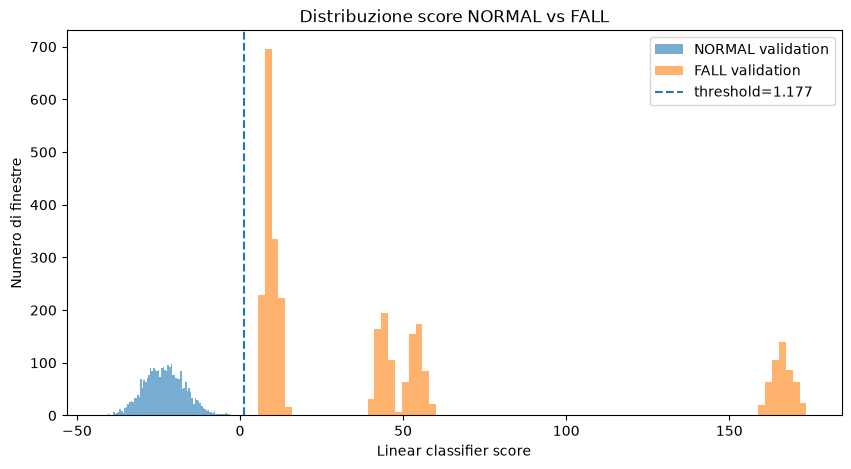

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(normal_validation_scores, bins=80, alpha=0.6, label="NORMAL validation")
plt.hist(fall_validation_scores, bins=80, alpha=0.6, label="FALL validation")
plt.axvline(
    FALL_BINARY_DECISION_THRESHOLD,
    linestyle="--",
    label=f"threshold={FALL_BINARY_DECISION_THRESHOLD:.4g}",
)
plt.xlabel("Linear classifier score")
plt.ylabel("Numero di finestre")
plt.title("Distribuzione score NORMAL vs FALL")
plt.legend()
plt.show()


## 11. Sanity check equivalente al codice C

Questa funzione replica esattamente l'inferenza che faremo nel nodo Contiki.


In [27]:
def c_style_binary_score(features: np.ndarray) -> float:
    features = np.asarray(features, dtype=np.float64)

    if features.shape != (NUM_FEATURES,):
        raise ValueError(f"Expected {(NUM_FEATURES,)}, got {features.shape}")

    score = FALL_BINARY_BIAS

    for feature_id in range(NUM_FEATURES):
        z = (
            features[feature_id] - FALL_BINARY_FEATURE_MEAN[feature_id]
        ) / FALL_BINARY_FEATURE_SCALE[feature_id]

        score += FALL_BINARY_WEIGHTS[feature_id] * z

    return float(score)


def predict_window(window: np.ndarray) -> dict:
    features = extract_features(window)
    score = c_style_binary_score(features)
    is_fall = score >= FALL_BINARY_DECISION_THRESHOLD

    return {
        "state": "FALL" if is_fall else "NORMAL",
        "score": float(score),
        "threshold": float(FALL_BINARY_DECISION_THRESHOLD),
    }


fall_example = add_fall_noise(TEST_FALL_TEMPLATES[0], np.random.default_rng(123))
normal_example = generate_normal_window(np.random.default_rng(456))

print("Example FALL:", predict_window(fall_example))
print("Example NORMAL:", predict_window(normal_example))

# Verifica equivalenza con sklearn su alcuni campioni.
for i in range(10):
    manual_score = c_style_binary_score(X_test[i])
    sklearn_score = float(model.decision_function(X_test[i:i+1])[0])

    if not np.isclose(manual_score, sklearn_score, rtol=1e-5, atol=1e-5):
        raise RuntimeError(
            f"C-style score mismatch at {i}: manual={manual_score}, sklearn={sklearn_score}"
        )

print("C-style inference matches sklearn decision_function.")


Example FALL: {'state': 'FALL', 'score': 66.34189466368032, 'threshold': 1.1766168169489748}
Example NORMAL: {'state': 'NORMAL', 'score': -23.50385341690189, 'threshold': 1.1766168169489748}
C-style inference matches sklearn decision_function.


## 12. Esportazione del modello in C

Il file generato è:

```text
fall_binary_model.h
```

Contiene:

- medie delle feature
- scale delle feature
- pesi lineari
- bias
- soglia decisionale


In [28]:
def format_c_float(value: float) -> str:
    if not np.isfinite(value):
        raise ValueError(f"Non-finite value: {value}")

    text = f"{float(value):.9g}"

    if "e" not in text.lower() and "." not in text:
        text += ".0"

    return text + "f"


def c_vector(name: str, vector: np.ndarray) -> str:
    values = ", ".join(format_c_float(value) for value in vector)

    return (
        f"static const float {name}[{len(vector)}] = {{\n"
        f"  {values}\n"
        f"}};"
    )


def build_c_header() -> str:
    return f'''#ifndef FALL_BINARY_MODEL_H_
#define FALL_BINARY_MODEL_H_

#define FALL_BINARY_NUM_FEATURES {NUM_FEATURES}

{c_vector("FALL_BINARY_FEATURE_MEAN", FALL_BINARY_FEATURE_MEAN)}

{c_vector("FALL_BINARY_FEATURE_SCALE", FALL_BINARY_FEATURE_SCALE)}

{c_vector("FALL_BINARY_WEIGHTS", FALL_BINARY_WEIGHTS)}

static const float FALL_BINARY_BIAS =
  {format_c_float(FALL_BINARY_BIAS)};

static const float FALL_BINARY_DECISION_THRESHOLD =
  {format_c_float(FALL_BINARY_DECISION_THRESHOLD)};

#endif /* FALL_BINARY_MODEL_H_ */
'''


header_text = build_c_header()
print(header_text[:1200])


#ifndef FALL_BINARY_MODEL_H_
#define FALL_BINARY_MODEL_H_

#define FALL_BINARY_NUM_FEATURES 21

static const float FALL_BINARY_FEATURE_MEAN[21] = {
  1171944.84f, 2.08332116e+12f, 259735.692f, 5558219.15f, 5298483.46f, 874592.097f, 4983700.74f, 3801.58784f, 146778533.0f, 17.8015f, 35412.693f, 35394.8915f, 4855.51226f, 30704.1378f, 1168667.61f, 1.95451675e+12f, 265774.36f, 5386002.63f, 5120228.27f, 853819.654f, 4815723.84f
};

static const float FALL_BINARY_FEATURE_SCALE[21] = {
  286592.765f, 3.54309808e+12f, 217869.67f, 4192295.94f, 4204076.99f, 547437.32f, 4308502.07f, 2989.82117f, 294786013.0f, 17.888663f, 39764.7924f, 39758.033f, 4001.34446f, 34023.9668f, 304538.01f, 3.36245406e+12f, 209442.686f, 4114646.6f, 4108083.9f, 541890.22f, 4214243.87f
};

static const float FALL_BINARY_WEIGHTS[21] = {
  4.49717757f, -0.725636633f, -2.87234075f, -0.123407977f, 0.0257923842f, -9.2462107f, 7.79964148f, 10.7350814f, 4.86523287f, 0.458596065f, 13.8855447f, 13.8876991f, -1.51759404f, 5.71458518f

## 13. Salvataggio degli artefatti

Gli artefatti vengono salvati nella cartella:

```text
fall_binary_artifacts/
```


In [29]:
OUTPUT_DIR = Path("fall_binary_artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

np.save(OUTPUT_DIR / "fall_binary_feature_mean.npy", FALL_BINARY_FEATURE_MEAN)
np.save(OUTPUT_DIR / "fall_binary_feature_scale.npy", FALL_BINARY_FEATURE_SCALE)
np.save(OUTPUT_DIR / "fall_binary_weights.npy", FALL_BINARY_WEIGHTS)
np.save(OUTPUT_DIR / "fall_binary_scores_validation.npy", validation_scores)
np.save(OUTPUT_DIR / "fall_binary_scores_test.npy", test_scores)

(OUTPUT_DIR / "fall_binary_model.h").write_text(header_text)

metrics = {
    "model_type": "binary_logistic_regression",
    "decision_threshold": float(FALL_BINARY_DECISION_THRESHOLD),
    "threshold_method": threshold_method,
    "target_recall": float(TARGET_RECALL),

    "train_template_ids": TRAIN_TEMPLATE_IDS.tolist(),
    "test_template_ids": TEST_TEMPLATE_IDS.tolist(),
    "num_train_templates": int(len(TRAIN_TEMPLATE_IDS)),
    "num_test_templates": int(len(TEST_TEMPLATE_IDS)),

    "train_metrics": {
        key: value
        for key, value in train_metrics.items()
        if key != "confusion_matrix"
    },
    "validation_metrics": {
        key: value
        for key, value in validation_metrics.items()
        if key != "confusion_matrix"
    },
    "heldout_test_metrics": {
        key: value
        for key, value in test_metrics.items()
        if key != "confusion_matrix"
    },

    "train_confusion_matrix": train_metrics["confusion_matrix"].tolist(),
    "validation_confusion_matrix": validation_metrics["confusion_matrix"].tolist(),
    "heldout_test_confusion_matrix": test_metrics["confusion_matrix"].tolist(),

    "train_variants_per_template": TRAIN_VARIANTS_PER_TEMPLATE,
    "validation_variants_per_template": VALIDATION_VARIANTS_PER_TEMPLATE,
    "normal_train_windows": NUM_NORMAL_TRAIN_WINDOWS,
    "normal_validation_windows": NUM_NORMAL_VALIDATION_WINDOWS,
    "normal_test_windows": NUM_NORMAL_TEST_WINDOWS,
    "random_seed": RANDOM_SEED,
}

(OUTPUT_DIR / "metrics_binary.json").write_text(
    json.dumps(metrics, indent=2)
)

print("Saved artifacts in:", OUTPUT_DIR.resolve())
print("Files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)


Saved artifacts in: /Users/susannabaldo/Desktop/IoT/IoT Project/smart-guard/machine_learning_notebook/fall_binary_artifacts
Files:
- fall_binary_feature_mean.npy
- fall_binary_feature_scale.npy
- fall_binary_model.h
- fall_binary_scores_test.npy
- fall_binary_scores_validation.npy
- fall_binary_weights.npy
- metrics_binary.json


## 14. Nota metodologica

Questo modello è diverso dal precedente modello a prototipi.

Il modello precedente chiedeva:

```text
quanto questa finestra è vicina a uno specifico prototipo FALL?
```

Il nuovo modello chiede:

```text
questa finestra assomiglia di più a NORMAL o a FALL?
```

Per questo è più adatto allo split con template held-out: può imparare una separazione generale tra movimento normale e caduta.
